In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import streamlit as st
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from xgboost import XGBRegressor

df = pd.read_csv('power_trading_demand_data_2025.csv')
df

,Unnamed: 0,timestamp,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,...,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,renewable_gen,renewable_pct,net_demand,demand_change_30m,daily_spread,load_factor,is_demand_outlier
0,0,2025-01-01 00:00:00,1,21036,26215,19918,5405,6606,0,19270,...,NaN,NaN,19918.000000,5405,0.271363,14513,NaN,NaN,NaN,False
1,1,2025-01-01 00:30:00,2,21222,26063,20167,5358,6606,0,19270,...,NaN,NaN,20042.500000,5358,0.265682,14809,249.0,21368.0,0.651909,False
2,2,2025-01-01 01:00:00,3,21385,25734,20328,5237,6606,0,19270,...,19918.0,NaN,20137.666667,5237,0.257625,15091,161.0,22683.0,0.615470,False
3,3,2025-01-01 01:30:00,4,20473,24988,19460,5115,6606,0,19270,...,20167.0,NaN,19968.250000,5115,0.262847,14345,-868.0,23771.0,0.629484,False
4,4,2025-01-01 02:00:00,5,19634,24912,18654,5080,6606,0,19270,...,20328.0,NaN,19705.400000,5080,0.272328,13574,-806.0,23419.0,0.614771,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17515,17515,2025-12-31 21:30:00,44,28633,30690,26868,3994,6606,0,22126,...,29072.0,29056.0,28162.041667,3994,0.148653,22874,-1028.0,NaN,NaN,False
17516,17516,2025-12-31 22:00:00,45,27381,30212,25722,4027,6606,0,22126,...,27896.0,27917.0,28116.312500,4027,0.156559,21695,-1146.0,NaN,NaN,False
17517,17517,2025-12-31 22:30:00,46,26563,29786,25049,4059,6606,0,22126,...,26868.0,26598.0,28084.041667,4059,0.162042,20990,-673.0,NaN,NaN,False
17518,17518,2025-12-31 23:00:00,47,25481,30558,23955,4115,6606,0,22126,...,25722.0,25493.0,28052.000000,4115,0.171780,19840,-1094.0,NaN,NaN,False


In [3]:
df.drop('Unnamed: 0', axis='columns', inplace=True)
df.head()

,timestamp,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,...,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,renewable_gen,renewable_pct,net_demand,demand_change_30m,daily_spread,load_factor,is_demand_outlier
0,2025-01-01 00:00:00,1,21036,26215,19918,5405,6606,0,19270,0,...,NaN,NaN,19918.000000,5405,0.271363,14513,NaN,NaN,NaN,False
1,2025-01-01 00:30:00,2,21222,26063,20167,5358,6606,0,19270,0,...,NaN,NaN,20042.500000,5358,0.265682,14809,249.0,21368.0,0.651909,False
2,2025-01-01 01:00:00,3,21385,25734,20328,5237,6606,0,19270,0,...,19918.0,NaN,20137.666667,5237,0.257625,15091,161.0,22683.0,0.615470,False
3,2025-01-01 01:30:00,4,20473,24988,19460,5115,6606,0,19270,0,...,20167.0,NaN,19968.250000,5115,0.262847,14345,-868.0,23771.0,0.629484,False
4,2025-01-01 02:00:00,5,19634,24912,18654,5080,6606,0,19270,0,...,20328.0,NaN,19705.400000,5080,0.272328,13574,-806.0,23419.0,0.614771,False


In [7]:
# using linear regression to predict england wales demand

newdf = df.drop(['nd', 'tsd', 'net_demand', 'embedded_wind_generation', 'embedded_solar_generation', 'pump_storage_pumping', 'ifa_flow', 'viking_flow', 'scottish_transfer', 'non_bm_stor', 'timestamp', 'demand_change_30m', 'daily_spread', 'load_factor', 'is_demand_outlier', 'ifa2_flow', 'britned_flow', 'moyle_flow', 'east_west_flow', 'nemo_flow', 'nsl_flow', 'eleclink_flow'], axis='columns')

In [9]:
newdf

,settlement_period,england_wales_demand,embedded_wind_capacity,embedded_solar_capacity,greenlink_flow,day,month,year,hour,minute,...,is_weekend,is_morning_peak,is_evening_peak,night,lagged_demand_30m,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,renewable_gen,renewable_pct
0,1,19918,6606,19270,0,1,1,2025,0,0,...,False,False,False,True,NaN,NaN,NaN,19918.000000,5405,0.271363
1,2,20167,6606,19270,0,1,1,2025,0,30,...,False,False,False,True,19918.0,NaN,NaN,20042.500000,5358,0.265682
2,3,20328,6606,19270,0,1,1,2025,1,0,...,False,False,False,True,20167.0,19918.0,NaN,20137.666667,5237,0.257625
3,4,19460,6606,19270,0,1,1,2025,1,30,...,False,False,False,True,20328.0,20167.0,NaN,19968.250000,5115,0.262847
4,5,18654,6606,19270,0,1,1,2025,2,0,...,False,False,False,True,19460.0,20328.0,NaN,19705.400000,5080,0.272328
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17515,44,26868,6606,22126,-514,31,12,2025,21,30,...,False,False,False,False,27896.0,29072.0,29056.0,28162.041667,3994,0.148653
17516,45,25722,6606,22126,-514,31,12,2025,22,0,...,False,False,False,False,26868.0,27896.0,27917.0,28116.312500,4027,0.156559
17517,46,25049,6606,22126,-514,31,12,2025,22,30,...,False,False,False,False,25722.0,26868.0,26598.0,28084.041667,4059,0.162042
17518,47,23955,6606,22126,-514,31,12,2025,23,0,...,False,False,False,True,25049.0,25722.0,25493.0,28052.000000,4115,0.171780


In [23]:
# data cleaning stage (filling Na values)

newdf['lagged_demand_30m'] = newdf['lagged_demand_30m'].fillna(newdf['lagged_demand_30m'].mean())
newdf['lagged_demand_1h'] = newdf['lagged_demand_1h'].fillna(newdf['lagged_demand_1h'].mean())
newdf['lagged_demand_24h'] = newdf['lagged_demand_24h'].fillna(newdf['lagged_demand_24h'].mean())


In [31]:
# x = features, y = label (Linear Regression Model)

x = newdf.drop('england_wales_demand', axis='columns')
y = df['england_wales_demand']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

linear_regression = LinearRegression()

linear_regression.fit(x_train, y_train)

linear_regression.score(x_test, y_test)

# Linear Regression model is achieving 0.99 accuracy upon first test (without parameter provision)

0.993889167498755

In [39]:
# x = features, y = label (RandomForest Regression Model)

x = newdf.drop('england_wales_demand', axis='columns')
y = df['england_wales_demand']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

randomforest_regression = RandomForestRegressor()

randomforest_regression.fit(x_train, y_train)

randomforest_regression.score(x_test, y_test)

# RandomForest Regression model is achieving 0.99 accuracy upon first test (without parameter provision)

0.9956387843632731

In [41]:
# x = features, y = label (Gradient Boosting Regression Model)

x = newdf.drop('england_wales_demand', axis='columns')
y = df['england_wales_demand']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

gradientb_regression = GradientBoostingRegressor()

gradientb_regression.fit(x_train, y_train)

gradientb_regression.score(x_test, y_test)

# GradientBoosting Regression model is achieving 0.99 accuracy upon first test (without parameter provision)

0.9954580765613158

In [49]:
# x = features, y = label (Gradient Boosting Regression Model)

x = newdf.drop('england_wales_demand', axis='columns')
y = df['england_wales_demand']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

xgb_regression = XGBRegressor()

xgb_regression.fit(x_train, y_train)

xgb_regression.score(x_test, y_test)

# XGB Regression model is achieving 0.99 accuracy upon first test (without parameter provision)

0.9970650809659343

In [57]:
# The models are achieving high scores as energy demand doesnt change drastically ever 30 mins

# we can use TimeSeriesSplit to split data chronologically and build a Pipeline


# This prevents the model from cheating by looking at future rows

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

tscv = TimeSeriesSplit(n_splits=3)


# The pipeline scales the data first and then feeds it to the model

model_params = {
    'lr': {
        'model': Pipeline([('scaler', StandardScaler()), ('regressor', LinearRegression())]),
        'params': {}  
    },
    'rf': {
        'model': Pipeline([('scaler', StandardScaler()), ('regressor', RandomForestRegressor(random_state=42))]),
        'params': {
            'regressor__n_estimators': [50, 100],
            'regressor__max_depth': [10, 20, None]
        }
    },
    'gb': {
        'model': Pipeline([('scaler', StandardScaler()), ('regressor', GradientBoostingRegressor(random_state=42))]),
        'params': {
            'regressor__n_estimators': [50, 100],
            'regressor__learning_rate': [0.05, 0.1]
        }
    },
    'xgb': {
        'model': Pipeline([('scaler', StandardScaler()), ('regressor', XGBRegressor(random_state=42))]),
        'params': {
            'regressor__n_estimators': [50, 100],
            'regressor__learning_rate': [0.05, 0.1],
            'regressor__max_depth': [3, 6]
        }
    }
}

scores = []


for model_name, mp in model_params.items():
    print(f"Running GridSearchCV for {model_name}")
    

    clf = GridSearchCV(mp['model'], mp['params'], cv=tscv, n_jobs=-1, scoring='r2')
    clf.fit(x_train, y_train)
    
    scores.append({
        'model': model_name,
        'best_score_R2': clf.best_score_,
        'best_params': clf.best_params_
    })


scoresdf = pd.DataFrame(scores, columns=['model', 'best_score_R2', 'best_params'])
scoresdf

Running GridSearchCV for lr


Running GridSearchCV for rf


Running GridSearchCV for gb


Running GridSearchCV for xgb


,model,best_score_R2,best_params
0,lr,0.993776,{}
1,rf,0.994763,"{'regressor__max_depth': 20, 'regressor__n_est..."
2,gb,0.995273,"{'regressor__learning_rate': 0.1, 'regressor__..."
3,xgb,0.996490,"{'regressor__learning_rate': 0.1, 'regressor__..."


In [ ]:
# XGB gives us the best result

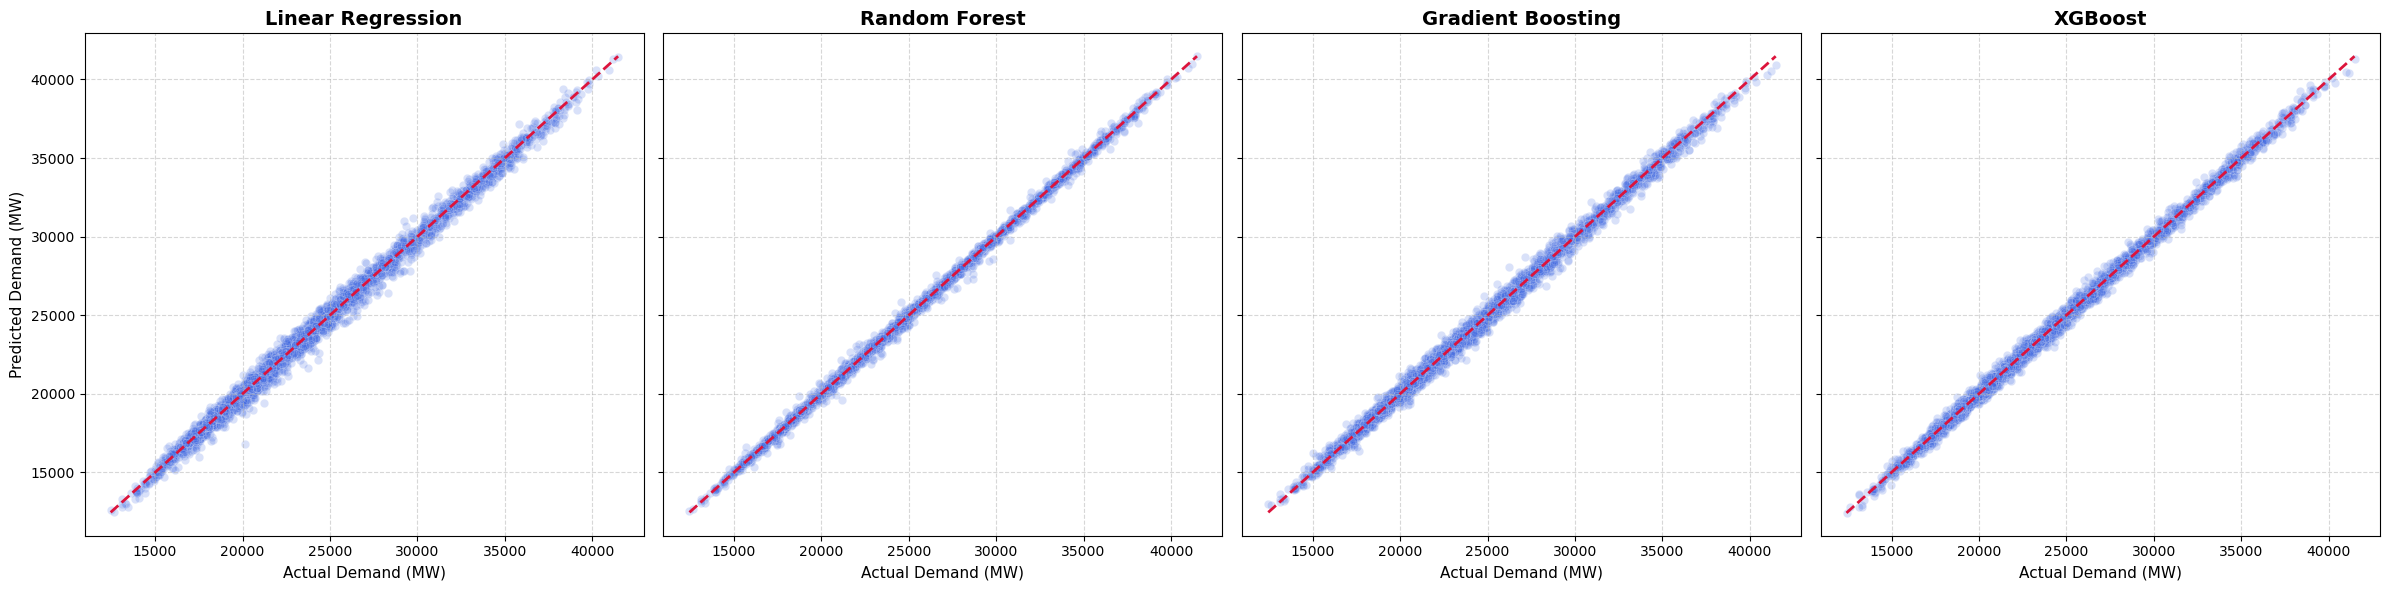

In [77]:
# plots for each model showing predicted vs actual points

trained_models = {
    'Linear Regression': linear_regression,
    'Random Forest': randomforest_regression,
    'Gradient Boosting': gradientb_regression,
    'XGBoost': xgb_regression
}


fig, axes = plt.subplots(1, 4, figsize=(24, 6), sharex=True, sharey=True)
axes = axes.flatten()


for idx, (name, model) in enumerate(trained_models.items()):
    ax = axes[idx]
    

    y_pred = model.predict(x_test)
    

    sn.scatterplot(x=y_test, y=y_pred, alpha=0.2, color='royalblue', ax=ax)
    

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], color='crimson', linestyle='--', linewidth=2)
    

    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_xlabel('Actual Demand (MW)', fontsize=11)
    

    if idx == 0:
        ax.set_ylabel('Predicted Demand (MW)', fontsize=11)
        
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()